<a href="https://colab.research.google.com/github/Listpiquito/TareaExa/blob/main/AnalisisNodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [422]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [423]:
#funciones

In [424]:
def modelo_Standing(Pr, J, Pb, Pwft, rw, re, S):
    Q = []
    EF = (np.log(0.472*(re/rw))) / ((np.log(0.472*(re/rw))) + S)
    J1 = J / EF

    if EF < 1:
        if Pr < Pb:
            for pwf in Pwft:
                if pwf > 0:
                    Qt = ((J1*Pr)/1.8)*((1.8*EF*(1-(pwf/Pr))) - (0.8*(EF**2)*((1-(pwf/Pr))**2)))
                    Q.append(round(float(Qt), 3))
                if pwf == 0:
                    Qt = ((J1*Pr)/1.8)*((1.8*EF) - (0.8*(EF**2)))
                    Q.append(round(float(Qt), 3))

        if Pr > Pb:
            for pwf in Pwft:
                if pwf >= Pb:
                    Qt = J * (Pr - pwf)
                    Q.append(round(float(Qt), 3))
                if pwf < Pb and pwf > 0:
                    Qt = (J*(Pr - Pb)) + (((J*Pb)/1.8)*((1.8*(1-(pwf/Pb))) - (0.8*EF*((1-(pwf/Pb))**2))))
                    Q.append(round(float(Qt), 3))
                if pwf == 0:
                    Qt = (J*(Pr - Pb)) + (((J*Pb)/1.8)*(1.8 - (0.8*EF)))
                    Q.append(round(float(Qt), 3))

    if EF > 1:
        # restric = Pr*(1-(1/EF))
        if Pr < Pb:
            for pwf in Pwft:
                if pwf > 0:
                    Qt = ((J1*Pr)/1.8)*((1.8*EF*(1-(pwf/Pr))) - (0.8*(EF**2)*((1-(pwf/Pr))**2)))
                    Q.append(round(float(Qt), 3))
                if pwf == 0:
                    Qt = ((J1*Pr)/1.8)*(0.624 + (0.376*EF))
                    Q.append(round(float(Qt), 3))

        if Pr > Pb:
            for pwf in Pwft:
                if pwf >= Pb:
                    Qt = J * (Pr - pwf)
                    Q.append(round(float(Qt), 3))
                if pwf < Pb and pwf > 0:
                    Qt = (J*(Pr - Pb)) + (((J*Pb)/1.8)*((1.8*(1-(pwf/Pb))) - (0.8*EF*((1-(pwf/Pb))**2))))
                    Q.append(round(float(Qt), 3))
                if pwf == 0:
                    Qt = (J*(Pr - Pb)) + (((J1*Pb)/1.8)*(0.624 + 0.376*(EF)))
                    Q.append(round(float(Qt), 3))

    return Q

In [455]:
def grafica_IPR(Pr, Pb, QT, Pwft, Qb):

    if Pb == 0:
        plt.figure(figsize=(10,8))  # tamaño opcional
        plt.plot(QT,Pwft, marker='o', color='b', linewidth=2)

        # Etiquetas y título
        plt.title("Curva IPR - Modelo de Darcy", fontsize=14)
        plt.ylabel("Presión de fondo fluyente Pwf (psi)", fontsize=12)
        plt.xlabel("Tasa de producción Q (bbl/día)", fontsize=12)
        # Cuadrícula y visualización
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.ylim(0, Pr)
        plt.yticks(np.linspace(0, Pr, 9))
        plt.show()

    if Pr < Pb:
        plt.figure(figsize=(10,8))  # tamaño opcional
        plt.plot(QT,Pwft, marker='o', color='b', linewidth=2)

        # Etiquetas y título
        plt.title("Curva IPR - yacimiento Saturado", fontsize=14)
        plt.ylabel("Presión de fondo fluyente Pwf (psi)", fontsize=12)
        plt.xlabel("Tasa de producción Q (bbl/día)", fontsize=12)
        # Cuadrícula y visualización
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.ylim(0, Pr)
        plt.yticks(np.linspace(0, Pr, 9))
        plt.show()

    if Pr > Pb:
        plt.figure(figsize=(10,8))  # tamaño opcional
        plt.plot(QT,Pwft, marker='o', color='b', linewidth=2)
        # Agregar línea vertical punteada en Q = 1000
        plt.axvline(x= Qb, color='r', linestyle='--', linewidth=1.5, label='Q = 258.5 bbpd')
        plt.axhline(y= Pb, color='r', linestyle='--', linewidth=1.5, label='Q = 650 psi')
        # Etiquetas y título
        plt.title("Curva IPR - Yacimiento Subsaturado -----> Saturado", fontsize=14)
        plt.ylabel("Presión de fondo fluyente Pwf (psi)", fontsize=12)
        plt.xlabel("Tasa de producción Q (bbl/día)", fontsize=12)
        # Cuadrícula y visualización
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.ylim(0, Pr)
        plt.yticks(np.linspace(0, Pr, 9))
        plt.show()

In [426]:
#funciones para Hagedorn - Brown

In [427]:
#calculo de las velocidades superficiales y de la mezcla
def Velocidades_Superficial_Mezcla(d, Qo, GLR):
    A = (3.14*d**2)/4                #ft2
    Vsl = (Qo*5.6145)/(86400*A)      #ft/s
    Vsg = ((Qo*GLR)/86400)/A  #ft/s
    Vm = Vsl + Vsg                   #ft/s
    #print(A)
    #print(Vsl)
    #print(Vsg)
    #print(Vm)
    return A, Vsl, Vsg, Vm

In [428]:
#calculo del lambdas de liquido y gas
def Lb (Vm, d, Vsl, Vsg):
    Lb = 1.071 - 0.2218*(Vm**2/d)
    if Lb < 0.13:
        Lb = 0.13
    lambg = Vsg/Vm
    lambl = Vsl/Vm
    #print('Lb: ', np.round(Lb, 3))
    #print('lambg: ', np.round(lambg, 3))
    #print('lambl: ', np.round(lambl, 3))
    if lambg > Lb:
        flujo = 'NoBuble'
        #print('No hay flujo burbuja')
    else:
        flujo = 'Buble'
        #print('flujo burbuja')
    return lambg, lambl, flujo

In [429]:
def Numeros_adimensionales(Vsl,Dl,OT,Vsg,d,Uo):
    Nvl = 1.938*Vsl*(Dl/OT)**0.25   #Numero de velocidad del Liquido (Nvl)
    Nvg = 1.938*Vsg*(Dl/OT)**0.25   #Numero de velocidad del gas (Nvg)
    ND = 120.872*d*(Dl/OT)**0.5   #Numero de velocidad del diametro (ND)
    NL = 0.15726*Uo*(1/(Dl*OT**3))**0.25   #Numero de velocidad del viscosidad del liquido (Nd)
    #print('Nvl: ', np.round(Nvl, 3))
    #print('Nvg: ', np.round(Nvg, 3))
    #print('Nd: ', np.round(ND, 3))
    #print('NL: ', np.round(NL, 4))
    return Nvl, Nvg, ND, NL

In [430]:
def Holdup_HB (NL,Nvl,Nvg,ND, P):
    CNL = 0.061*NL**3 - 0.0929*NL**2 + 0.0505*NL + 0.0019
    H = (Nvl*(P**0.1)*CNL)/((Nvg**0.575)*(14.7**0.1)*ND)
    Hl_til = ((0.0047 + 1123.32*H + 729489.64*H**2)/(1 + 1097.1566*H + 722153.97*H**2))**0.5
    B = (Nvg*NL**0.380)/(ND**2.14)
    if B <= 0.025:
        til = 27170*B**3 - 317.52*B**2 + 0.5472*B + 0.9999
    if B > 0.025 and B <= 0.055:
        til = -533.33*B**2 + 58.524*B + 0.1171
    if B > 0.055:
        2.5714*B + 1.5962
    Hl = np.round(Hl_til * til, 3)
    #print('Hl: ', np.round(Hl, 4))
    return Hl

In [431]:
#Calculo de las densidades de la mezcla
def calculo_densidades (Dl, Dg, lambl, lambg, Hl):
    Dn = Dl*lambl + Dg*lambg    #lb/ft3       Densida mezcla sin deslizamiento
    Dm = Dl*Hl + Dg*(1-Hl)   #Lb/ft3          Densida mezcla con deslizamiento
    Df = Dn**2/Dm            #Lb/ft3          Densida mezcla del fluido
    #print('Dn: ', np.round(Dn, 3), 'lb/ft3')
    #print('Dm: ', np.round(Dm, 3), 'Lb/ft3')
    #print('Df: ', np.round(Df, 3), 'lb/ft3')
    return Dn, Dm, Df

In [432]:
#Calculo del factor de friccion
def factor_friccion_bifasico(Uo, Ug, Hl,Dn, Vm, d, e):
    Um = (Uo**Hl)*(Ug**(1-Hl))  #cp              viscosidad de la mezcla
    Nrem = (148*Dn*Vm*d)/Um                   #numero de reynolds
    f = (1/(1.14-2*np.log10((e/d)+(21.25/Nrem**0.9))))**2       #factor de friccion
    #print('Um: ', np.round(Um, 4), 'cp')
    #print('Nrem: ', np.round(Nrem, 3))
    #print('f: ', np.round(f, 4))
    return Um, Nrem, f

In [433]:
#Calculo del gradiente de presion
def Gradiente_de_presion(Dm, Ang, f, Df, Vm, d):
    GPE = ((Dm*np.cos((Ang*3.14)/180))/144)#+ 0.1   #psi/ft       Gradiente de presion por elevacion
    GPf = ((2*f*Df*Vm**2)/(32.17*d*144))#+ 0.02      #psi/ft       Gradiente de presion por friccion
    GP = GPE + GPf                          #psi/ft       Gradiente de presion total
    #print('GPE: ', np.round(GPE, 3), 'psi/ft')
    #print('GPf: ', np.round(GPf, 3), 'psi/ft')
    #print('GP: ', np.round(GP, 3), 'psi/ft')
    return GP

In [434]:
def Gradiente_Presion_Griffith(Dm, Dl, Qo, f, d, Vm, Vsg):
    Ga = Dm/144
    Vs = 0.8
    Yl = 1 - (1/2)*(1 + (Vm/Vs) - (((1 + (Vm/Vs))**2) - 4*(Vsg/Vs))**0.5)
    ml = Dl*Qo
    Gf = (f*ml**2)/(74130000000*144*Yl*d**5)
    GP = Ga + Gf
    #print(GP)
    return GP

In [435]:
#correlaciones PVT

In [436]:
def Expancion_gas_Z(P,T,Eg):
    #print('expansion de gas Z')
    Tpc = 170.5 + 307.3*Eg
    #print('Tpc', Tpc)
    Ppc = 709.6 -58.7*Eg
    #print('Ppc', Ppc)
    Ppr = P/Ppc
    #print('Ppr', Ppr)
    Tpr = (T+460)/Tpc
    #print('Tpr', Tpr)
    A = 1.39*((Tpr-0.92)**0.5)-0.36*Tpr-0.101
    #print('A', A)
    B = Ppr*(0.62 -0.23*Tpr)+(Ppr**2)*((0.066/(Tpr-0.86))-0.037)+((0.132*Ppr**6)/2.72**(20.723*(Tpr-1)))
    #print('B', B)
    C = 0.132-0.32*np.log10(Tpr)
    #print('C', C)
    D = 2.72**(0.715 -1.128*Tpr + 0.42*Tpr**2)
    #print('D', D)
    Z = A + (1 - A)*2.72**-B + C*Ppr**D
    #print('Z', Z)
    return Z

In [437]:
def Razon_solubilidad_Rs (P, T, API, Eg):
    #print('Razon de solubilidad')
    X = 0.0125*API - 0.00091*T
    #print('X', X)
    Rs = Eg*((P/18.2+1.4)*10**X)**1.2048
    #print('Rs', Rs)
    return Rs

In [438]:
def Factor_volumetrico_Bo(Rs, Eg, Eo, T):
    #print('factor volumetrico')
    Bo = 0.9759 + 0.000120*(Rs*(Eg/Eo)**0.5+1.25*T)**1.2
    #print('Bo', Bo)
    return Bo

In [439]:
def Viscosidad_oil_Uo(API, T, Rs):
    #print('Viscosidad Uo')
    X = 10**((3.0324 - 0.02023*API)*(T**-1.163))
    #print('X', X)
    Uod = 10**X - 1
    #print('Uod', Uod)
    a = 10.715*(Rs + 100)**-0.515
    #print('a', a)
    b = 5.44*(Rs + 150)**-0.338
    #print('b', b)
    Uo = a*Uod**b
    #print('Uo', Uo)
    return Uo

In [440]:
def Viscosidad_gas_Ug(Eg, T, P, Z):
    #print('viscocidad ug')
    M = 28.97 * Eg
    #print('M', M)
    A = ((9.4 + 0.02*M)*((T+460)**1.5))/(209 + 19*M + (T+460))
    #print('A', A)
    B = 3.5 + 0.01*M + 986/(T+460)
    #print('B', B)
    C = 2.4 - 0.2*B
    #print('C', C)
    Dg = (0.0433*Eg*P)/(Z*(T+460))
    #print('Dg', Dg)
    Ug = A*0.0001*2.72**(B*Dg**C)
    #print('Ug', Ug)
    return Ug

In [441]:
def Tension_interfacial_TO(API, T, PP):
    #print('tension interfacial')
    O68 = 39 - 0.2571*API
    #print('O68', O68)
    O100 = 37.5 - 0.2571*API
    #print('O100', O100)
    OT = O68 - (((T-68)*(O68-O100))/32)
    #print('OT', OT)
    C = 1 - 0.024*PP**0.45
    #print('C', C)
    TO = C*OT
    #print('TO', TO)
    return TO

In [442]:
######################################################################################################################################################

In [443]:
######################################################################################################################################################

In [444]:
#Programa principal#

In [445]:
#calculos para pozo - curva IPR

In [446]:
#Datos de presion y caudal
Pr = 3200 #psi
Pb = 800 #psi
J=1.5
#Pwft = [2341.7, 2300, 2200, 2100, 2000, 1900, 1800, 1700, 1600,1500, 1400,1300, 1200, 1100, 1031, 900, 800, 700, 600, 500, 400, 300, 200, 100, 0] #psi
Pwft = np.linspace(Pr, 0, 21)

In [447]:
#Datos petrofisiscos
K = 164.41    #md
h = 16     #ft
Bo = 1.27    #bbl/stb
uo = 0.79    #cp
rw = 0.354     #ft
re = 10000  #ft
S = 14.5

In [448]:
QT = modelo_Standing(Pr, J, Pb, Pwft, rw, re, S)
#print(QT)
AOF = QT[-1]
print('El caudal maximo (AOF): ', AOF, 'bbpd')



El caudal maximo (AOF):  4588.915 bbpd


In [449]:
#Dataframe
Tabla_datos = pd.DataFrame({
    'Pwf (psi)': Pwft,
    'Q (bbl/día)': QT
})
print(Tabla_datos)

    Pwf (psi)  Q (bbl/día)
0      3200.0        0.000
1      3040.0      240.000
2      2880.0      480.000
3      2720.0      720.000
4      2560.0      960.000
5      2400.0     1200.000
6      2240.0     1440.000
7      2080.0     1680.000
8      1920.0     1920.000
9      1760.0     2160.000
10     1600.0     2400.000
11     1440.0     2640.000
12     1280.0     2880.000
13     1120.0     3120.000
14      960.0     3360.000
15      800.0     3600.000
16      640.0     3831.557
17      480.0     4046.226
18      320.0     4244.010
19      160.0     4424.906
20        0.0     4588.915


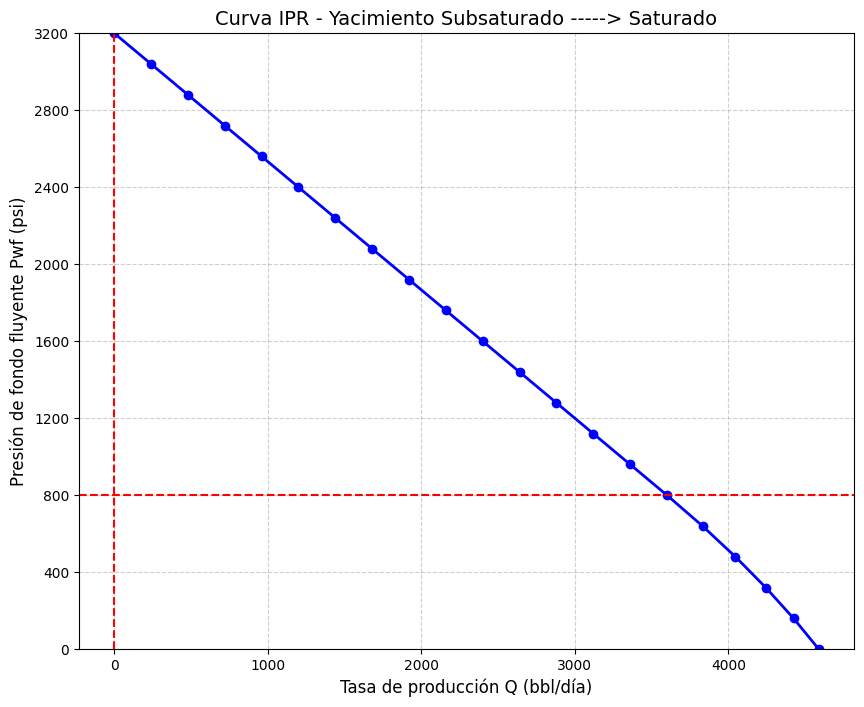

In [450]:
Grafica = grafica_IPR(Pr, Pb, QT, Pwft, Qb=0)

In [ ]:
#calculos para pozo VLP

In [ ]:
qo = [32.02, 106.726, 178.494, 247.324, 313.215, 376.169, 436.185, 493.262, 547.402, 598.603, 646.867, 692.192, 734.58, 762.114, 810.541, 844.114, 874.749, 902.446, 927.206, 949.027, 967.91, 983.855, 996.862, 1006.931]
fw = 0.80
GOR = 30
GLR = GOR*(1-fw)
Pb = Pwh #psi
T = 90   #f
Pa = 14.7   #Psi
Eg = 0.7
Eo = 0.83
API = 40
Do = 47.61 #lb/ft3
Dg = 5.88  #lb/ft3
Dw = 63.0  #lb/ft3
Dl = Do*(1-fw) + Dw*fw
d =  2.88/12     #in
e = 0.0006 #ft
L = 7000  #ft
Ang = 0
difL = 500
cortes = L/difL
segmentos = np.full(int(cortes), difL)
difPasum = 30

In [ ]:
pwfo = []
for Qo in qo:
    for seg in segmentos:
        Pp = (Pb+(Pb+difPasum))/2
        Tp = (T + (T + 8))/2
        Z = Expancion_gas_Z(Pp,T,Eg)
        Rs = Razon_solubilidad_Rs (Pp, Tp, API, Eg)
        Bo = Factor_volumetrico_Bo(Rs, Eg, Eo, Tp)
        Uo = Viscosidad_oil_Uo(API, Tp, Rs)
        Ug = Viscosidad_gas_Ug(Eg, Tp, Pp, Z)
        OT = Tension_interfacial_TO(API, Tp, Pp)
        #print('Presion promedio: ', PP)
        #print('Z: ', np.round(Z,3))
        #print('Rs: ', np.round(Rs,3))
        #print('Bo: ', np.round(Bo,3))
        #print('Uo: ', np.round(Uo,3))
        #print('Ug: ', np.round(Ug,3))
        #print('TO: ', np.round(TO,3))
        #calculo de las velocidades superficiales y de la mezcla
        A, Vsl, Vsg, Vm = Velocidades_Superficial_Mezcla(d, Qo, GLR)
        #calculo de Lb, Lambg, lambl
        lambg, lambl, flujo = Lb (Vm, d, Vsl, Vsg)
        #calculo de nuemeros adimensionales
        Nvl, Nvg, ND, NL = Numeros_adimensionales(Vsl,Dl,OT,Vsg,d,Uo)
        #calculo del hold up
        Hl = Holdup_HB (NL,Nvl,Nvg,ND, Pp)
        #Calculo de densidades
        Dn, Dm, Df = calculo_densidades (Dl, Dg, lambl, lambg, Hl)
        #Calculo del factor de friccion
        Um, Nrem, f = factor_friccion_bifasico(Uo, Ug, Hl,Dn, Vm, d, e)
        #calculo del gradiente de preseion
        if flujo == 'NoBuble':
            GP = Gradiente_de_presion(Dm, Ang, f, Df, Vm, d)
        if flujo == 'Buble':
            GP = Gradiente_Presion_Griffith(Dm, Dl, Qo, f, d, Vm, Vsg)
        deltP = difL*GP
        Pb = Pb + deltP
        T = Tp
    pwfo.append(float(np.round(Pb, 3)))
    Pb = Pwh
    T = 90
print(pwfo)
pwfo = [1059.275, 1110.503, 1178.99, 1228.61, 1269.84, 1303.363, 1332.702, 1358.857, 1382.639, 1404.507, 1424.913, 1442.876, 1460.671, 1470.893, 1490.429, 1504.065, 1516.026, 1526.458, 1536.534, 1544.994, 1552.504, 1559.035, 1564.031, 1568.009]

In [ ]:
#Dataframe
Tabla_datos = pd.DataFrame({
    'Pwfo (psi)': pwfo,
    'Qo (bbl/día)': qo
})
print(Tabla_datos)

In [ ]:
plt.figure(figsize=(8,6))  # tamaño opcional
plt.plot(QT,Pwft, marker='o', color='b', linewidth=2)
plt.plot(qo,pwfo, marker='o', color='r', linewidth=2)
# Etiquetas y título
plt.title("Curva Intersecion entre IPR -VLP", fontsize=14)
plt.ylabel("Presión de fondo fluyente Pwf (psi)", fontsize=12)
plt.xlabel("Tasa de producción Q (bbl/día)", fontsize=12)
# Cuadrícula y visualización
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
######################################################################################################################################################

In [ ]:
######################################################################################################################################################

In [ ]:
#Pozo SHS - 14

In [ ]:
#calculos para pozo - curva IPR

In [ ]:
#Datos de presion y caudal
Regimen = 'E'
Pr = 4000 #psi
Pb = 2000 #psi
Pwft = [4000, 3800, 3600, 3400, 3200, 3000, 2800, 2600, 2400, 2200, 2000, 1800, 1600, 1400, 1200, 1000, 800, 600, 400, 200, 0] #psi #psi

In [ ]:
#Datos petrofisiscos
K = 30    #md
h = 100     #ft
Bo = 1.32    #bbl/stb
uo = 6.4    #cp
rw = 0.32     #ft
re = 1000  #ft
S = 5

In [ ]:
#calculos del indice de productividad
if Regimen == 'T':
    J = IP_transitoria(K,h,Bo,u,t,Poro,Ct,Rw)
if Regimen == 'E' or Regimen == 'P':
    J = IP_estacionaria_Pseudoestacionaria(Regimen,K,h,Bo,uo,re,rw,S)
print('El indice de productividad es: ', J, 'bbpd/psi')

In [ ]:
QT = modelo_Fetkovich(Pr, J, Pb, Pwft, Pt1 =0, Qt1= 0, Pt2= 0, Qt2= 0)
print(QT)
AOF = QT[-1]
print('El caudal maximo (AOF): ', AOF, 'bbpd')
Qb = QT[Pwft.index(Pb)]
print('Qb: ', Qb, 'bbpd')

In [ ]:
#Dataframe
Tabla_datos = pd.DataFrame({
    'Pwf (psi)': Pwft,
    'Q (bbl/día)': QT
})
print(Tabla_datos)

In [ ]:
Grafica = grafica_IPR(Pr, Pb, QT, Pwft, Qb)

In [ ]:
#Calculos presion de cabeza

In [ ]:
P = 50 #Psi
qo = 470.438 #stb/d
Qo = (qo*5.615)/86400   #ft/s
GOR = 300
fw = 0.8
GLR = GOR*(1-fw)
Qg = (qo*GLR)/86400 #scf/d
D = 2.5 #in
T = 70 #F
Eg = 0.7
Eo = 0.83
API = 40
Ang = 0
L = 3000 #ft
difPasum = 30
difL = 500
segmentos = L/difL
iteraciones = 0
cumple = True
seg = np.full(int(segmentos), difL)

In [ ]:
for corte in seg:
    while cumple:
        #calcular propiedades de los fluidos
        PP = (P+(P+difPasum))/2
        Z = Expancion_gas_Z(PP,T,Eg)
        Rs = Razon_solubilidad_Rs (PP, T, API, Eg) #scf/stb
        Bo = Factor_volumetrico_Bo(Rs, Eg, Eo, T)  #bbl/stb
        Uo = Viscosidad_oil_Uo(API, T, Rs)   #cp
        Ug = Viscosidad_gas_Ug(Eg, T, PP, Z)   #cp
        TO = Tension_interfacial_TO(API, T, PP)  #dinas/cm
        #print('Presion promedio: ', PP)
        #print('Z: ', np.round(Z,3))
        #print('Rs: ', np.round(Rs,3))
        #print('Bo: ', np.round(Bo,3))
        #print('Uo: ', np.round(Uo,3))
        #print('Ug: ', np.round(Ug,3))
        #print('TO: ', np.round(TO,3))
        #calculo de densidades y caudales in-situs
        Do, Dg, qo, qg = Densidades_Caudales_insitu(Eo, Rs, Eg, Bo, PP, Z, T, Qo, Qg)
        #calcular velocidades surpeficiales in-situ
        A, Vsl, Vsg, Vm = Velocidades_fluidos(D,Qo,Qg)
        #Determinar patrones de flujo
        lambL, Nfroud, Nvl, L1, L2, L3, L4 = Numeros_Froud_Adimensionales(Vsl, Vm, D, Do, TO)
        Hl = Regimen_flujo(lambL, Nfroud, Nvl, Ang, L1, L2, L3, L4)
        #Calculo de las densidades
        DenS, DenN = Densidades_ConDeslizamiento_SinDeslizamiento(Do, Dg, Hl, lambL)
        #calculo del factor de friccion bifasico
        Un, ftp = Factor_de_friccion_bifasico_BB(Uo, Ug, lambL, DenN, Vm, D, Hl)
        #calculo del gradiente de presion
        GP = Gradientes_Presion(DenS, Ang, ftp, DenN, Vm, D, Vsg, PP)
        #Caida de presion
        deltP = GP*corte
        if np.round(deltP, 3) == np.round(difPasum, 3):
            iteraciones = iteraciones + 1
            #print('iteracion: ', iteraciones)
            #print('dif P calculado: ', np.round(deltP, 3))
            #print(' ')
            cumple = False
        if np.round(deltP, 3) != np.round(difPasum, 3):
            iteraciones = iteraciones + 1
            #print('iteracion: ', iteraciones)
            #print('dif Pasumido: ', np.round(difPasum, 3))
            #print('dif Pcalculado: ', np.round(deltP, 3))
            difPasum = deltP
            #print(' ')
        if iteraciones == 20:
            cumple = False
    P = P + np.round(deltP, 3)#Psi
Pwh = P
print(' la presion de cabeza (Pwh): ', np.round(Pwh, 3), 'Psi')

In [ ]:
#calculos para pozo VLP

In [ ]:
qo = [38.6, 77.2, 115.8, 154.4, 193.0, 231.6, 270.2, 308.8, 347.4, 386.0, 422.67, 455.48, 484.43, 509.52, 530.75, 548.12, 561.63, 571.28, 577.07, 579.0]
GOR = 300
fw = 0.8
GLR = GOR*(1-fw)
Pb = Pwh #psi
T = 70   #f
Pa = 14.7   #Psi
Eg = 0.7
Eo = 0.83
API = 40
Do = 44.79 #lb/ft3
Dg = 3.27  #lb/ft3
Dw = 50.13  #lb/ft3
Dl = Do*(1-fw) + Dw*fw
d =  2/12     #in
e = 0.0006 #ft
L = 9000  #ft
Ang = 0
difL = 500
cortes = L/difL
segmentos = np.full(int(cortes), difL)
difPasum = 30

In [ ]:
pwfo = []
for Qo in qo:
    for seg in segmentos:
        Pp = (Pb+(Pb+difPasum))/2
        Tp = (T + (T + 8))/2
        Z = Expancion_gas_Z(Pp,T,Eg)
        Rs = Razon_solubilidad_Rs (Pp, Tp, API, Eg)
        Bo = Factor_volumetrico_Bo(Rs, Eg, Eo, Tp)
        Uo = Viscosidad_oil_Uo(API, Tp, Rs)
        Ug = Viscosidad_gas_Ug(Eg, Tp, Pp, Z)
        OT = Tension_interfacial_TO(API, Tp, Pp)
        #calculo de las velocidades superficiales y de la mezcla
        A, Vsl, Vsg, Vm = Velocidades_Superficial_Mezcla(d, Qo, GLR)
        #calculo de Lb, Lambg, lambl
        lambg, lambl, flujo = Lb (Vm, d, Vsl, Vsg)
        #calculo de nuemeros adimensionales
        Nvl, Nvg, ND, NL = Numeros_adimensionales(Vsl,Dl,OT,Vsg,d,Uo)
        #calculo del hold up
        Hl = Holdup_HB (NL,Nvl,Nvg,ND, Pp)
        #Calculo de densidades
        Dn, Dm, Df = calculo_densidades (Dl, Dg, lambl, lambg, Hl)
        #Calculo del factor de friccion
        Um, Nrem, f = factor_friccion_bifasico(Uo, Ug, Hl,Dn, Vm, d, e)
        #calculo del gradiente de preseion
        if flujo == 'NoBuble':
            GP = Gradiente_de_presion(Dm, Ang, f, Df, Vm, d)
        if flujo == 'Buble':
            GP = Gradiente_Presion_Griffith(Dm, Dl, Qo, f, d, Vm, Vsg)
        deltP = difL*GP
        Pb = Pb + deltP
        T = Tp
    pwfo.append(float(np.round(Pb, 3)))
    Pb = 254
    T = 84
print(pwfo)

In [ ]:
#Dataframe
Tabla_datos = pd.DataFrame({
    'Pwfo (psi)': pwfo,
    'Qo (bbl/día)': qo
})
print(Tabla_datos)

In [ ]:
plt.figure(figsize=(8,6))  # tamaño opcional
plt.plot(QT,Pwft, marker='o', color='b', linewidth=2)
plt.plot(qo,pwfo, marker='o', color='r', linewidth=2)
# Etiquetas y título
plt.title("Curva IPR - yacimiento Saturado", fontsize=14)
plt.ylabel("Presión de fondo fluyente Pwf (psi)", fontsize=12)
plt.xlabel("Tasa de producción Q (bbl/día)", fontsize=12)
# Cuadrícula y visualización
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
######################################################################################################################################################

In [ ]:
######################################################################################################################################################

In [ ]:
#Pozo SHS - 56

In [ ]:
#calculos para pozo - curva IPR

In [ ]:
#Datos de presion y caudal
Regimen = 'P'
Pr = 3300 #psi
Pb = 1000 #psi
Pwft = [3300, 3000, 2700, 2500, 2300, 2000, 1700, 1500, 1300, 1000, 700, 500, 300, 0] #psi #psi

In [ ]:
#Datos petrofisiscos
K = 60    #md
h = 80     #ft
Bo = 1.32    #bbl/stb
uo = 6.4    #cp
rw = 0.32     #ft
re = 800  #ft
S = 2

In [ ]:
#calculos del indice de productividad
if Regimen == 'T':
    J = IP_transitoria(K,h,Bo,u,t,Poro,Ct,Rw)
if Regimen == 'E' or Regimen == 'P':
    J = IP_estacionaria_Pseudoestacionaria(Regimen,K,h,Bo,uo,re,rw,S)
print('El indice de productividad es: ', J, 'bbpd/psi')

In [ ]:
QT = modelo_Fetkovich(Pr, J, Pb, Pwft, Pt1 =0, Qt1= 0, Pt2= 0, Qt2= 0)
print(QT)
AOF = QT[-1]
print('El caudal maximo (AOF): ', AOF, 'bbpd')
Qb = QT[Pwft.index(Pb)]
print('Qb: ', Qb)

In [ ]:
#Dataframe
Tabla_datos = pd.DataFrame({
    'Pwf (psi)': Pwft,
    'Q (bbl/día)': QT
})
print(Tabla_datos)

In [ ]:
Grafica = grafica_IPR(Pr, Pb, QT, Pwft, Qb)

In [ ]:
#Calculos presion de cabeza

In [ ]:
P = 150 #Psi
qo = 1185.025 #stb/d
Qo = (qo*5.615)/86400   #ft/s
GOR = 150
fw = 0.9
GLR = GOR*(1-fw)
Qg = (qo*GLR)/86400 #scf/d
D = 2.5 #in
T = 85 #F
Eg = 0.63
Eo = 0.8
API = 40
Ang = 0
L = 4500 #ft
difPasum = 30
difL = 500
segmentos = L/difL
iteraciones = 0
cumple = True
seg = np.full(int(segmentos), difL)

In [ ]:
for corte in seg:
    while cumple:
        #calcular propiedades de los fluidos
        PP = (P+(P+difPasum))/2
        Z = Expancion_gas_Z(PP,T,Eg)
        Rs = Razon_solubilidad_Rs (PP, T, API, Eg) #scf/stb
        Bo = Factor_volumetrico_Bo(Rs, Eg, Eo, T)  #bbl/stb
        Uo = Viscosidad_oil_Uo(API, T, Rs)   #cp
        Ug = Viscosidad_gas_Ug(Eg, T, PP, Z)   #cp
        TO = Tension_interfacial_TO(API, T, PP)  #dinas/cm
        #print('Presion promedio: ', PP)
        #print('Z: ', np.round(Z,3))
        #print('Rs: ', np.round(Rs,3))
        #print('Bo: ', np.round(Bo,3))
        #print('Uo: ', np.round(Uo,3))
        #print('Ug: ', np.round(Ug,3))
        #print('TO: ', np.round(TO,3))
        #calculo de densidades y caudales in-situs
        Do, Dg, qo, qg = Densidades_Caudales_insitu(Eo, Rs, Eg, Bo, PP, Z, T, Qo, Qg)
        #calcular velocidades surpeficiales in-situ
        A, Vsl, Vsg, Vm = Velocidades_fluidos(D,Qo,Qg)
        #Determinar patrones de flujo
        lambL, Nfroud, Nvl, L1, L2, L3, L4 = Numeros_Froud_Adimensionales(Vsl, Vm, D, Do, TO)
        Hl = Regimen_flujo(lambL, Nfroud, Nvl, Ang, L1, L2, L3, L4)
        #Calculo de las densidades
        DenS, DenN = Densidades_ConDeslizamiento_SinDeslizamiento(Do, Dg, Hl, lambL)
        #calculo del factor de friccion bifasico
        Un, ftp = Factor_de_friccion_bifasico_BB(Uo, Ug, lambL, DenN, Vm, D, Hl)
        #calculo del gradiente de presion
        GP = Gradientes_Presion(DenS, Ang, ftp, DenN, Vm, D, Vsg, PP)
        #Caida de presion
        deltP = GP*corte
        if np.round(deltP, 3) == np.round(difPasum, 3):
            iteraciones = iteraciones + 1
            #print('iteracion: ', iteraciones)
            #print('dif P calculado: ', np.round(deltP, 3))
            #print(' ')
            cumple = False
        if np.round(deltP, 3) != np.round(difPasum, 3):
            iteraciones = iteraciones + 1
            #print('iteracion: ', iteraciones)
            #print('dif Pasumido: ', np.round(difPasum, 3))
            #print('dif Pcalculado: ', np.round(deltP, 3))
            difPasum = deltP
            #print(' ')
        if iteraciones == 20:
            cumple = False
    P = P + np.round(deltP, 3)#Psi
Pwh = P
print(' la presion de cabeza (Pwh): ', np.round(Pwh, 3), 'Psi')

In [ ]:
#calculos para pozo VLP

In [ ]:
qo = [132.9, 265.8, 354.4, 443.0, 575.9, 708.8, 797.4, 886.0, 1018.9, 1131.865, 1185.025, 1220.465, 1240.4]
GOR = 150
fw = 0.90
GLR = GOR*(1-fw)
Pb = Pwh #psi
T = 85   #f
Pa = 14.7   #Psi
Eg = 0.63
Eo = 0.8
API = 40
Do = 48.3 #lb/ft3
Dg = 6.32  #lb/ft3
Dw = 57.13  #lb/ft3
Dl = Do*(1-fw) + Dw*fw
d =  2.5/12     #in
e = 0.0006 #ft
L = 8000  #ft
Ang = 0
difL = 500
cortes = L/difL
segmentos = np.full(int(cortes), difL)
difPasum = 30

In [ ]:
pwfo = []
for Qo in qo:
    for seg in segmentos:
        Pp = (Pb+(Pb+difPasum))/2
        Tp = (T + (T + 8))/2
        Z = Expancion_gas_Z(Pp,T,Eg)
        Rs = Razon_solubilidad_Rs (Pp, Tp, API, Eg)
        Bo = Factor_volumetrico_Bo(Rs, Eg, Eo, Tp)
        Uo = Viscosidad_oil_Uo(API, Tp, Rs)
        Ug = Viscosidad_gas_Ug(Eg, Tp, Pp, Z)
        OT = Tension_interfacial_TO(API, Tp, Pp)
        #calculo de las velocidades superficiales y de la mezcla
        A, Vsl, Vsg, Vm = Velocidades_Superficial_Mezcla(d, Qo, GLR)
        #calculo de Lb, Lambg, lambl
        lambg, lambl, flujo = Lb (Vm, d, Vsl, Vsg)
        #calculo de nuemeros adimensionales
        Nvl, Nvg, ND, NL = Numeros_adimensionales(Vsl,Dl,OT,Vsg,d,Uo)
        #calculo del hold up
        Hl = Holdup_HB (NL,Nvl,Nvg,ND, Pp)
        #Calculo de densidades
        Dn, Dm, Df = calculo_densidades (Dl, Dg, lambl, lambg, Hl)
        #Calculo del factor de friccion
        Um, Nrem, f = factor_friccion_bifasico(Uo, Ug, Hl,Dn, Vm, d, e)
        #calculo del gradiente de preseion
        if flujo == 'NoBuble':
            GP = Gradiente_de_presion(Dm, Ang, f, Df, Vm, d)
        if flujo == 'Buble':
            GP = Gradiente_Presion_Griffith(Dm, Dl, Qo, f, d, Vm, Vsg)
        deltP = difL*GP
        Pb = Pb + deltP
        T = Tp
    pwfo.append(float(np.round(Pb, 3)))
    Pb = 254
    T = 84
print(pwfo)

In [ ]:
#Dataframe
Tabla_datos = pd.DataFrame({
    'Pwfo (psi)': pwfo,
    'Qo (bbl/día)': qo
})
print(Tabla_datos)

In [ ]:
plt.figure(figsize=(8,6))  # tamaño opcional
plt.plot(QT,Pwft, marker='o', color='b', linewidth=2)
plt.plot(qo,pwfo, marker='o', color='r', linewidth=2)
# Etiquetas y título
plt.title("Curva IPR - yacimiento Saturado", fontsize=14)
plt.ylabel("Presión de fondo fluyente Pwf (psi)", fontsize=12)
plt.xlabel("Tasa de producción Q (bbl/día)", fontsize=12)
# Cuadrícula y visualización
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()